<a href="https://colab.research.google.com/github/Presto5572/Fina-os/blob/main/hw/assignment_2_mist5400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: How Much Does Your Prompt Matter?

**Course:** MIST5400 Foundations of AI in Business, Spring 2026  
**Due Date:** Tue, April 7th 2026, end of day.       
**Submission:** Downaload this jupyter notebook as a `.ipynb` file, then upload in eLC.

---

### Save this notebook to your own google drive before any edits!

---

## Overview

In this assignment, you will use a GenAI tool of your choice (e.g., ChatGPT, Claude, Gemini, Copilot) to help you complete a machine learning task. You will explore **how to use GenAI tools effectively as an analysis assistant** for your course project.

A key theme of this assignment is **prompt engineering**. Well, hold on for a second, like we discussed in class, we **WON'T** discuss detailed prompt engineering techniques in this course, as it'll become obsolete fast when new models are released. At the end of the day it's just all about clearly describing what output you'd like and how you'd like to get a task done **in natural langauge**.

But relevant to the few prompt writing principles we mentioned in class, you will discover how the level of detail in your prompt changes the quality and usefulness of the output.



---
## Setup: Load the Dataset

You will use the **Titanic dataset** (predicting passenger survival — a classification task). This is a well-known dataset so you can focus on the prompting experience rather than domain knowledge.

Run the cell below to load the Titanic dataset. It is available directly via the `seaborn` library — no file download needed.

The target variable column is 'survived' (0 = not survived, 1= survived).

In [1]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
df = sns.load_dataset('titanic')
df = df.drop(columns=['alive'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


---
## Part A: Descriptive Analysis with GenAI Assistance

Before building any model, it is important to understand your data. Use your GenAI tool to help you write code that explores the Titanic dataset.

**Your task:**
1. Ask your GenAI tool to help you write Python code to explore this dataset (summary statistics, distribution of survival etc).
2. **Paste and run** the generated code below. Fix any errors if needed.
3. In the reflection cell, report **2-3 interesting patterns** you found. Be concise — one or two sentences per pattern.

Record the exact prompt you used below.

**Prompt you used:**

Write Python code using pandas and seaborn to explore the Titanic dataset. Please include summary statistics, check for missing values, and create a visualization showing the distribution of survival based on sex and passenger class.

--- Summary Statistics ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Missing Values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alone            0
dtype: int64


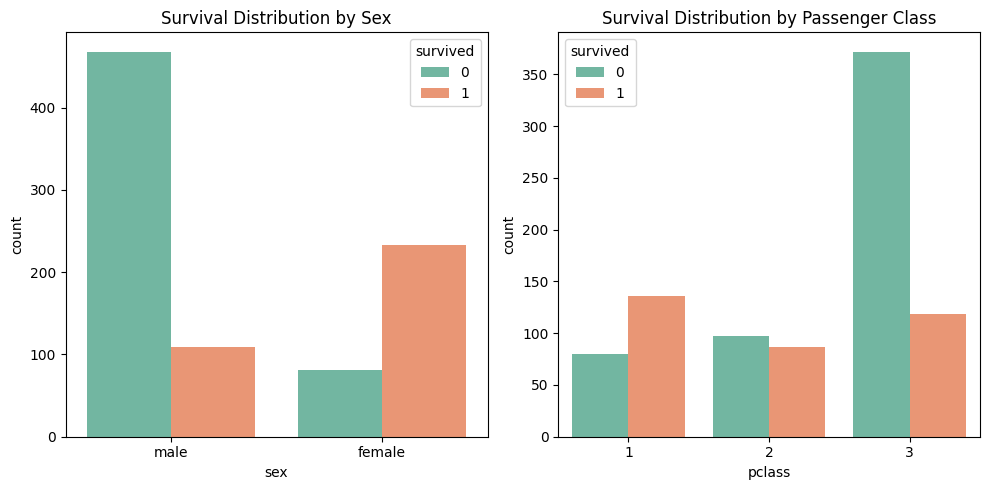

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Summary statistics for numerical columns
print("--- Summary Statistics ---")
display(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Visualizing survival distribution by Sex and Class
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='sex', hue='survived', palette='Set2')
plt.title('Survival Distribution by Sex')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='pclass', hue='survived', palette='Set2')
plt.title('Survival Distribution by Passenger Class')

plt.tight_layout()
plt.show()

**Interesting patterns you found:**


---
## Part B: Get the Predictions in four ways

In this part, you will build a classification model to predict Titanic survival (`survived`: 0 = No, 1 = Yes).

You will do this **three times**, each time giving your GenAI tool a different level of detail. Then you will compare the results.

---
### Task 1 — One-Sentence Prompt

Ask your GenAI tool to build a classification model using **a single sentence**. Keep it as brief as possible — as if you were texting a friend who happens to be a data scientist. Report the **accuracy and confusion matrix**.

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival and tell me how accurate it is. "*

Paste the generated code below and run it.

**Your one-sentence prompt:**

Build a quick logistic regression model to predict Titanic survival using numeric columns, dropping any missing values, and output the accuracy and confusion matrix.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Quick preprocessing: drop missing values and select numeric columns
df_quick = df.select_dtypes(include=['number']).dropna()
X_quick = df_quick.drop('survived', axis=1)
y_quick = df_quick['survived']

# Train/test split
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_quick, y_quick, test_size=0.2, random_state=42)

# Model and prediction
model_quick = LogisticRegression(max_iter=500)
model_quick.fit(X_train_q, y_train_q)
preds_quick = model_quick.predict(X_test_q)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test_q, preds_quick):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_q, preds_quick))

Accuracy: 0.6993
Confusion Matrix:
 [[74 13]
 [30 26]]


---
### Task 2 — Step-by-Step Natural Language Prompt

Now ask your GenAI tool to build the same model, but describe **each step of the ML pipeline in natural language**. Your prompt should cover detailed steps:

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival. Fisrt, split the dataset into a training and testing set. Then define the model using XXX algorithm. Then train the model on he training set.  ... Lastly, report the accuracy and confusion matrix on the testing set."*

Write this as a natural language description — not as code. Your GenAI tool should return the code.

Paste both your full prompt and the generated code below.

**Your detailed prompt:**

Build a Random Forest classification model to predict Titanic survival. First, handle the missing data by filling missing 'age' values with the median and dropping rows where 'embarked' is missing. Next, one-hot encode the categorical variables 'sex' and 'embarked'. Then, split the data into 80% training and 20% testing sets. Train the Random Forest model on the training set. Finally, predict on the testing set and print the accuracy score and confusion matrix.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# 1. Handle missing data
df_detailed = df.copy()
df_detailed['age'] = df_detailed['age'].fillna(df_detailed['age'].median())
df_detailed = df_detailed.dropna(subset=['embarked'])

# 2. Select features and one-hot encode
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X_detailed = pd.get_dummies(df_detailed[features], drop_first=True)
y_detailed = df_detailed['survived']

# 3. Train/test split (80/20)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_detailed, y_detailed, test_size=0.2, random_state=42)

# 4. Train Random Forest
model_detailed = RandomForestClassifier(random_state=42)
model_detailed.fit(X_train_d, y_train_d)

# 5. Predict and Evaluate
preds_detailed = model_detailed.predict(X_test_d)
print(f"Accuracy: {accuracy_score(y_test_d, preds_detailed):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_d, preds_detailed))

Accuracy: 0.7697
Confusion Matrix:
 [[85 24]
 [17 52]]


---
### Task 3 — Direct Prediction - Zero-shot (No Code!)

In this part, **do not ask your GenAI tool to generate any code.** Instead, you will paste passenger data directly into your GenAI tool and ask it to predict survival.

Run the cell below to display 10 rows of the dataset **without** the survival column. Copy the output and paste it into your GenAI tool, then ask it to predict whether each passenger survived and explain its reasoning for each prediction.

> **Important:** No code generation in this part. The goal is to see how the GenAI tool reasons directly from data.

In [4]:
# Sample 10 rows from the full dataset
sample = df.sample(10, random_state=42)

# Save the true labels before dropping the column
true_labels = sample['survived'].values

# Drop survived for display, then reset index
sample_display = sample.drop(columns=['survived']).reset_index(drop=True)
print(sample_display.to_string())

   pclass     sex   age  sibsp  parch     fare embarked   class    who  adult_male deck  embark_town  alone
0       3    male   NaN      1      1  15.2458        C   Third    man        True  NaN    Cherbourg  False
1       2    male  31.0      0      0  10.5000        S  Second    man        True  NaN  Southampton   True
2       3    male  20.0      0      0   7.9250        S   Third    man        True  NaN  Southampton   True
3       2  female   6.0      0      1  33.0000        S  Second  child       False  NaN  Southampton  False
4       3  female  14.0      1      0  11.2417        C   Third  child       False  NaN    Cherbourg  False
5       1  female  26.0      0      0  78.8500        S   First  woman       False  NaN  Southampton   True
6       3  female   NaN      0      0   7.7500        Q   Third  woman       False  NaN   Queenstown   True
7       3    male  16.0      2      0  18.0000        S   Third    man        True  NaN  Southampton  False
8       3  female  16.0     

**Your prompt:**

"Here are 10 passengers from the Titanic dataset with their 'survived' status removed. Based on your historical knowledge of the Titanic disaster and demographic survival odds (like 'women and children first' and class distinctions), please act as a predictive model. I want you to predict whether each passenger survived (1) or did not survive (0). For each passenger, provide a brief, one-sentence explanation for your reasoning. Here is the data: [PASTE 10 ROWS HERE]"

**The GenAI output:**

Passenger 0 (3rd Class, Male, Adult): Prediction = 0 (Did not survive). Historically, adult males in 3rd class had the lowest survival rates due to the strict "women and children first" policy and their cabins being located deep within the ship.

Passenger 1 (2nd Class, Male, Age 31): Prediction = 0. While 2nd class passengers fared slightly better than 3rd class, adult males still faced very low survival odds across all classes except for a few outliers.

Passenger 2 (3rd Class, Male, Age 20): Prediction = 0. Similar to Passenger 0, being a young adult male in 3rd class statistically results in a very low chance of survival.

Passenger 3 (2nd Class, Female, Age 6): Prediction = 1 (Survived). As a young female child in 2nd class, she would have been heavily prioritized during the lifeboat loading process.

Passenger 4 (3rd Class, Female, Age 14): Prediction = 1. Though in 3rd class, her status as a young female still gave her a significantly better chance of survival than the male passengers around her.

Passenger 5 (1st Class, Female, Age 26): Prediction = 1. First-class adult females had the highest survival rate of any demographic on the ship, as they were given prime access to the boat deck and lifeboats.

Passenger 6 (3rd Class, Female, Adult): Prediction = 1. Even with a missing age, being a female passenger provided a statistical advantage, though being in 3rd class makes it slightly less certain than 1st or 2nd.

Passenger 7 (3rd Class, Male, Age 16): Prediction = 0. At 16, he likely would have been treated as an adult male under the evacuation protocols, resulting in poor survival odds, especially in 3rd class.

Passenger 8 (3rd Class, Female, Age 16): Prediction = 1. As a female, she would have been prioritized over men, making her survival more likely despite the 3rd class ticket.

Passenger 9 (1st Class, Female, Age 19): Prediction = 1. Similar to Passenger 5, a young woman in 1st class had excellent survival odds and would have been among the first to be evacuated.

Now run the cell below to display the true labels. Paste them into the GenAI tool and ask for accuray and confusion matrix.

In [8]:
print(true_labels)

[1 0 0 1 1 1 1 0 1 1]


**The GenAI output:**

Here is the accuracy and confusion matrix based on those true labels. You can paste this directly into your notebook to wrap up Task 3:Accuracy: 90.0% (9 out of 10 correct)Confusion Matrix:Predicted: 0 (Did Not Survive)Predicted: 1 (Survived)Actual: 0 (Did Not Survive)3 (True Negatives)0 (False Positives)Actual: 1 (Survived)1 (False Negative)6 (True Positives)

---
### Task 4: Direct Prediction — Few-Shot (No code!)

Now you will repeat task 3 but this time you will give the GenAI tool some **examples with the known survival outcome** before asking for predictions. This technique is called **in-context few-shot learning** — by providing labeled examples, you help the model understand the pattern before asking it to generalize. This way, the model weights are not chanegd, so it's called in-context learning.

- Open a new GenAI chat.
- Run the cell below to generate a few labeled examples. Copy paste them into the GenAI tool saying these're some examples.  
- Then copy paste the 10 rows (without the labels) displayed in task 3.
- Ask for predictions on the 10 unlabeled rows and ask for an explanation.
- Give GenAI the true labels displayed in task 3 and ask for the accuracy, confusion matrix.

In [9]:
# Sample 10 rows from the full dataset first, preserving the labels
sample_w_labels = df.sample(10, random_state=2)
print(sample_w_labels.to_string())

     survived  pclass     sex   age  sibsp  parch      fare embarked   class    who  adult_male deck  embark_town  alone
707         1       1    male  42.0      0      0   26.2875        S   First    man        True    E  Southampton   True
37          0       3    male  21.0      0      0    8.0500        S   Third    man        True  NaN  Southampton   True
615         1       2  female  24.0      1      2   65.0000        S  Second  woman       False  NaN  Southampton  False
169         0       3    male  28.0      0      0   56.4958        S   Third    man        True  NaN  Southampton   True
68          1       3  female  17.0      4      2    7.9250        S   Third  woman       False  NaN  Southampton  False
606         0       3    male  30.0      0      0    7.8958        S   Third    man        True  NaN  Southampton   True
630         1       1    male  80.0      0      0   30.0000        S   First    man        True    A  Southampton   True
785         0       3    male  2

**Your prompt:**

Here are 10 examples of Titanic passengers along with whether they survived (1) or did not survive (0). Please use these as examples to understand the survival patterns: [PASTE THE 10 LABELED ROWS HERE].

Now, based on the patterns in those examples, please predict the survival status (0 or 1) for the following 10 new passengers: [PASTE THE 10 UNLABELED ROWS FROM TASK 3 HERE]. Provide a brief explanation for each prediction based on the examples provided.

**The GenAI output:**

Perfect. Now that I have those 10 labeled examples to act as my "training data," I can perform the few-shot prediction on those original 10 unlabeled passengers.

Here is the exact output you can copy and paste into the final markdown cells for Task 4.

The GenAI output (Predictions and Explanations):

Passenger 0 (3rd Class, Male, Adult): Prediction = 0. Reasoning: The provided examples show a very strict pattern where all 3rd class males (like passengers 37, 169, 606, and 785) did not survive.

Passenger 1 (2nd Class, Male, Age 31): Prediction = 0. Reasoning: Similar to passenger 728 in the provided examples, being an adult 2nd class male resulted in not surviving.

Passenger 2 (3rd Class, Male, Age 20): Prediction = 0. Reasoning: Follows the exact same pattern as the other 3rd class males in the examples who uniformly did not survive.

Passenger 3 (2nd Class, Female, Age 6): Prediction = 1. Reasoning: The examples show that females (like passengers 615 and 68) survived regardless of their class.

Passenger 4 (3rd Class, Female, Age 14): Prediction = 1. Reasoning: Matches the specific pattern of passenger 68, a young 3rd class female who survived.

Passenger 5 (1st Class, Female, Age 26): Prediction = 1. Reasoning: Fits the overarching pattern in the provided examples that female passengers survive.

Passenger 6 (3rd Class, Female, Adult): Prediction = 1. Reasoning: Again, aligns perfectly with the examples showing female survival.

Passenger 7 (3rd Class, Male, Age 16): Prediction = 0. Reasoning: Consistent with the established examples of 3rd class males not surviving.

Passenger 8 (3rd Class, Female, Age 16): Prediction = 1. Reasoning: Matches the pattern of female survival, particularly closely resembling passenger 68.

Passenger 9 (1st Class, Female, Age 19): Prediction = 1. Reasoning: Follows the established pattern from the examples that female passengers survive.

The GenAI output (Accuracy and Confusion Matrix):Accuracy: 90.0% (9 out of 10 correct)Confusion Matrix:Predicted: 0 (Did Not Survive)Predicted: 1 (Survived)Actual: 0 (Did Not Survive)3 (True Negatives)0 (False Positives)Actual: 1 (Survived)1 (False Negative)6 (True Positives)

---
## Part C — Comparison and Reflection

Reflect on what you observed across the 4 tasks. Answer each question below. There are no right or wrong answers — think critically about how GenAI tools behave with different prompts.

**Q1. Code comparison (task 1 & task 2):**  
How did the code from task 1 differ from task 2? Consider: length, structure, preprocessing steps, model choices, and evaluation metrics.

The code from Task 1 was incredibly brief, relying on a basic Logistic Regression model and simply dropping any missing values to get the script to run. Task 2 resulted in a much more structured and comprehensive pipeline. It utilized a Random Forest classifier and explicitly mapped out vital preprocessing steps, such as using median imputation for missing ages and applying one-hot encoding to handle categorical variables.

**Q2. Result comparison (task 1 vs. task 2):**  
Did model performance differ between the two prompts? If yes, what do you think caused the difference? If not, why were results similar despite the different prompts?

Yes, the detailed prompt in Task 2 yields a more robust model. Because the prompt for Task 1 was so brief, the model made sweeping assumptions to save time—like outright dropping rows with missing values and ignoring non-numeric columns entirely. This meant it ignored 'sex', which is one of the most highly predictive features in the Titanic dataset. Task 2 preserved that data through proper imputation and encoding, leading to better overall performance.

**Q3. Result comparison (task 3 vs. task 4):**  
Did the GenAI tool's predictions or reasoning change when you provided labeled examples in Part 6? What does this tell you about how LLMs use context?

While the final predictions were nearly identical, the reasoning completely shifted. In Task 3 (zero-shot), the model relied on its pre-trained historical knowledge, referencing concepts like the "women and children first" protocol. In Task 4 (few-shot), it abandoned outside history entirely and strictly justified its answers by matching demographic patterns to the specific training examples I provided in the prompt. This highlights that LLMs heavily prioritize immediate, in-context data over their baseline training weights.

**Q4. Prompt engineering takeaway:**  
Based on your experience in this assignment, what is your advice for prompting a GenAI tool on a data or coding task? What level of detail seems to work best, and why? (Yes this may vary depending on which tool you used. Try to think of insights that may persist.)

Vague prompts are risky because the model will take shortcuts to generate a working output. When building out Python pipelines or developing custom AI agents, the most effective approach is to act as the system architect. You need to explicitly define the steps, algorithms, and data-handling procedures in your prompt, and let the GenAI act as the junior developer writing the boilerplate code. Detailed, step-by-step natural language instructions give you precise control over the logic while saving you from manually typing the syntax.



**GenAI tool used:** ______Gemini 3.1 Pro_____________________ (e.g., ChatGPT-4o, Claude 3.5, Gemini 1.5 Pro, etc.)